# Effects of derandomization on e-power

**Antisymmetric vs. growth-rate-optimal (GRO) e-variables in a Gaussian linear model.**

We test whether a feature $X$ matters for predicting $Y$ by comparing the loss of a fixed predictor on the
real $X$ with its loss on a fresh, independent copy $\tilde X$ (Model-X). A single copy $\tilde X$ injects
extra randomness into the test; **derandomization** averages the e-variable over $K$ independent copies
to remove it. This notebook asks how much each kind of e-variable gains from that averaging.

All distributions in this model are available in closed form, so every density used below is exact —
nothing is estimated.

In [1]:
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate
from scipy.special import expit, kve      # kve(0, z) = K_0(z) * exp(z)

LOG_2PI = np.log(2.0 * np.pi)
_TINY = 1e-300


# ---------------------------------------------------------------- model ----
@dataclass(frozen=True)
class Model:
    """Y = beta X + eps with a *fixed* guess beta_hat (no regression is run)."""

    beta: float
    beta_hat: float

    def __post_init__(self):
        if self.beta_hat == 0.0:
            raise ValueError("beta_hat = 0 gives q == q_tilde identically (degenerate).")

    @property
    def delta(self):
        return self.beta - self.beta_hat

    def moments(self):
        """(sigma_U^2, sigma_V^2, Cov(U,V)) for U = Y - bh*X, V = Y - bh*X_tilde."""
        d, b = self.delta, self.beta_hat
        su2 = 1.0 + d * d
        sv2 = 1.0 + d * d + 2.0 * b * d + 2.0 * b * b
        cuv = 1.0 + d * d + b * d
        return su2, sv2, cuv

    def diff_params(self):
        """(P, T, S) = (det Sigma, sigma_V^2 - sigma_U^2, sqrt(T^2 + 4P))."""
        su2, sv2, cuv = self.moments()
        P = su2 * sv2 - cuv * cuv          # = beta_hat^2 (2 + delta^2)
        T = sv2 - su2                      # = 2 beta beta_hat
        return P, T, float(np.sqrt(T * T + 4.0 * P))

    @property
    def tilt(self):
        """kappa = T/(2P): the exponential tilt of f_D and the GRO slope."""
        P, T, _ = self.diff_params()
        return T / (2.0 * P)


# ------------------------------------------------------------ densities ----
# All of these are the *single* X_tilde densities.  Derandomization below
# deliberately does NOT change them.

def marginal_q_logpdf(q, model):
    """log f_q(q):  q ~ (1 + delta^2) * chi^2_1."""
    q = np.asarray(q, dtype=float)
    su2, _, _ = model.moments()
    return -0.5 * (LOG_2PI + np.log(su2) + np.log(q)) - q / (2.0 * su2)


def joint_logpdf(q, q_tilde, model):
    """log f_{q,q~}(a,b) on (0,inf)^2 -- squares of a centred bivariate normal."""
    a = np.asarray(q, dtype=float)
    b = np.asarray(q_tilde, dtype=float)
    su2, sv2, cuv = model.moments()
    P = su2 * sv2 - cuv * cuv
    x = cuv * np.sqrt(a * b) / P
    log_cosh = np.abs(x) + np.log1p(np.exp(-2.0 * np.abs(x))) - np.log(2.0)
    return (-LOG_2PI - 0.5 * np.log(P) - 0.5 * (np.log(a) + np.log(b))
            - (sv2 * a + su2 * b) / (2.0 * P) + log_cosh)


def joint_pdf(q, q_tilde, model):
    return np.exp(joint_logpdf(q, q_tilde, model))


def conditional_logpdf(q_tilde, q, model):
    """
    log f_{q~|q}(b|a), the "(mu + N)^2" route: given q, U = +/- sqrt(q) with
    probability 1/2 each and V|U ~ N((c/su2) U, P/su2), so q~|q is a scaled
    non-central chi^2_1 mixed over the sign of U.  Equals joint - marginal.
    """
    b = np.asarray(q_tilde, dtype=float)
    a = np.asarray(q, dtype=float)
    su2, sv2, cuv = model.moments()
    P = su2 * sv2 - cuv * cuv
    tau2 = P / su2
    m = (cuv / su2) * np.sqrt(a)
    z = np.sqrt(b) * m / tau2
    log_cosh = np.abs(z) + np.log1p(np.exp(-2.0 * np.abs(z))) - np.log(2.0)
    return (-0.5 * (LOG_2PI + np.log(tau2) + np.log(b))
            - (b + m * m) / (2.0 * tau2) + log_cosh)


def diff_logpdf(d, model):
    """log f_D(d) for D = q~ - q:  (2 pi sqrt(P))^-1 exp(Td/4P) K_0(S|d|/4P)."""
    d = np.asarray(d, dtype=float)
    P, T, S = model.diff_params()
    z = np.maximum(S * np.abs(d) / (4.0 * P), _TINY)
    return (-LOG_2PI - 0.5 * np.log(P) + T * d / (4.0 * P)
            + np.log(kve(0.0, z)) - z)          # log K_0(z) = log kve(0,z) - z


def diff_pdf(d, model):
    return np.exp(diff_logpdf(d, model))


def quad_real_line(f):
    """int_R f, split at the log singularity of f_D at 0."""
    lo, _ = integrate.quad(f, -np.inf, 0.0, limit=400)
    hi, _ = integrate.quad(f, 0.0, np.inf, limit=400)
    return lo + hi


# ----------------------------------------------------------- simulation ----
def simulate(model, n, K, rng):
    """
    Returns q of shape (n,) and q_tilde of shape (n, K).

    The K copies of X_tilde are drawn independently *for the same* (X, Y),
    which is exactly what derandomization averages over.  Column 0 alone
    reproduces the original, single-draw experiment.
    """
    X = rng.standard_normal(n)
    eps = rng.standard_normal(n)
    Y = model.beta * X + eps
    X_tilde = rng.standard_normal((n, K))
    q = (Y - model.beta_hat * X) ** 2
    q_tilde = (Y[:, None] - model.beta_hat * X_tilde) ** 2
    return q, q_tilde


# ---------------------------------------------------------- e-variables ----
def e_power(e):
    """Empirical e-power: average of log e over the n observations."""
    return float(np.mean(np.log(e)))


def e_gro_diff(D, model):
    """2 f_D(d) / (f_D(d) + f_D(-d)), from the single-X_tilde density of D."""
    return 2.0 * expit(diff_logpdf(D, model) - diff_logpdf(-D, model))


def e_gro_exch(q, q_tilde, model):
    """2 f(q,q~) / (f(q,q~) + f(q~,q)), from the single-X_tilde joint density."""
    return 2.0 * expit(joint_logpdf(q, q_tilde, model)
                       - joint_logpdf(q_tilde, q, model))


def h_bar(D, name, M=None):
    """
    Derandomized odd statistic h_bar_i = mean_k h(D_ik), |h_bar| <= 1.
    D has shape (n, K); K = 1 is the non-derandomized experiment.
    """
    if name == "sign":
        h = np.sign(D)
    elif name == "tanh":
        h = np.tanh(D)
    elif name == "clip":
        h = np.clip(D, -M, M) / M
    else:
        raise ValueError(name)
    return h.mean(axis=1)


def affine_e_power(h, lam):
    """e-power of 1 + lam * h_bar.  Since 1 + lam*h is affine in h, this IS the
    e-power of the derandomized e-variable (the average of 1 + lam*h(D_k))."""
    with np.errstate(divide="ignore"):
        return float(np.mean(np.log1p(lam * h)))


def best_lambda(h, lam_grid):
    """argmax over the lambda grid of  mean_i log(1 + lambda * h_bar_i)."""
    with np.errstate(divide="ignore"):
        powers = np.log1p(lam_grid[:, None] * h[None, :]).mean(axis=1)
    i = int(np.argmax(powers))
    return float(lam_grid[i]), float(powers[i])


ANTISYMMETRIC = ["sign", "tanh", "clip"]


def tune(q, q_tilde, lam_grid, m_grid):
    """
    Choose (lambda, M) for each antisymmetric e-variable on a PRETRAINING draw.
    q_tilde has K columns, so the parameters are tuned after derandomizing
    at that same K.
    """
    D = q_tilde - q[:, None]
    params = {}
    for name in ["sign", "tanh"]:
        lam, _ = best_lambda(h_bar(D, name), lam_grid)
        params[name] = dict(lam=lam, M=None)
    best = (-np.inf, None, None)
    for M in m_grid:
        lam, pw = best_lambda(h_bar(D, "clip", M), lam_grid)
        if pw > best[0]:
            best = (pw, lam, float(M))
    params["clip"] = dict(lam=best[1], M=best[2])
    return params


def evaluate(q, q_tilde, model, params):
    """
    e-power of the five e-variables on an EVALUATION draw, with the
    antisymmetric parameters held fixed at `params` (from `tune`).
    q: (n,), q_tilde: (n, K).  Every e-variable is replaced by its average
    over the K X_tilde draws; K = 1 is the non-derandomized experiment.
    """
    D = q_tilde - q[:, None]
    res = {}
    for name in ANTISYMMETRIC:
        lam, M = params[name]["lam"], params[name]["M"]
        res[name] = dict(e_power=affine_e_power(h_bar(D, name, M), lam), lam=lam, M=M)

    res["gro_diff"] = dict(e_power=e_power(e_gro_diff(D, model).mean(1)),
                           lam=None, M=None)
    res["gro_exch"] = dict(e_power=e_power(e_gro_exch(q[:, None], q_tilde, model).mean(1)),
                           lam=None, M=None)
    return res


METHODS = ANTISYMMETRIC + ["gro_diff", "gro_exch"]
LABELS = {"sign": "1 + lam*sign(D)", "tanh": "1 + lam*tanh(D)",
          "clip": "1 + lam*clip(D,M)/M", "gro_diff": "GRO (difference)",
          "gro_exch": "GRO (exchangeability)"}


ARMS = ["K1", "retuned", "frozen"]


def run_arms(q_pre, q_tilde_pre, q, q_tilde, model, lam_grid, m_grid, params_1=None):
    """
    One seed, one K (= number of columns of q_tilde).  Returns the three arms,
    all evaluated on the same evaluation draw:
      K1      : column 0 only, parameters tuned at K = 1
      retuned : all K columns, parameters re-tuned at K       (arm A)
      frozen  : all K columns, the K = 1 parameters reused     (arm B)
    The GRO e-variables have no parameters, so retuned == frozen for them (arm C).
    """
    if params_1 is None:
        params_1 = tune(q_pre, q_tilde_pre[:, :1], lam_grid, m_grid)
    params_K = tune(q_pre, q_tilde_pre, lam_grid, m_grid)
    return dict(K1=evaluate(q, q_tilde[:, :1], model, params_1),
                retuned=evaluate(q, q_tilde, model, params_K),
                frozen=evaluate(q, q_tilde, model, params_1))


def mean_se(x):
    """Mean and standard error over seeds."""
    x = np.asarray(x, dtype=float)
    se = x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else np.nan
    return float(x.mean()), float(se)


def summarize(runs, model):
    """
    Aggregate a list of run_arms outputs (one per seed) into mean +/- SE of
    the e-power per arm, the relative gain over K = 1 per arm (computed per
    seed, then averaged; None under the null, where the K = 1 e-power is ~0),
    and the tuned parameters.
    """
    is_null = model.tilt == 0.0
    out = {}
    for m in METHODS:
        row = {arm: mean_se([r[arm][m]["e_power"] for r in runs]) for arm in ARMS}
        for arm in ["retuned", "frozen"]:
            row["gain_" + arm] = None if is_null else mean_se(
                [(r[arm][m]["e_power"] - r["K1"][m]["e_power"]) / abs(r["K1"][m]["e_power"])
                 for r in runs])
        for p in ["lam", "M"]:
            for arm in ["K1", "retuned"]:
                vals = [r[arm][m][p] for r in runs]
                row[f"{p}_{arm}"] = None if vals[0] is None else mean_se(vals)
        out[m] = row
    return out


def fmt(ms, digits=5):
    return f"{ms[0]:.{digits}f} ± {ms[1]:.{digits}f}"


def fmt_gain(ms):
    return "—" if ms is None else f"{100 * ms[0]:+.1f}% ± {100 * ms[1]:.1f}"


def print_block(model, summary, K, n_seeds):
    """Arms A/B/C side by side for one (beta, beta_hat) setting, mean ± SE over seeds."""
    print(f"beta = {model.beta:+.2f},  beta_hat = {model.beta_hat:+.2f}   "
          f"(kappa = {model.tilt:+.3f},  null iff kappa = 0;  {n_seeds} seeds)")
    print(f"  {'e-variable':22s} {'K=1':>19} {'K=' + str(K) + ' re-tuned':>19} "
          f"{'K=' + str(K) + ' frozen':>19}   {'gain re-tuned':>15} {'gain frozen':>15}")
    for m in METHODS:
        s = summary[m]
        print(f"  {LABELS[m]:22s} {fmt(s['K1']):>19} {fmt(s['retuned']):>19} "
              f"{fmt(s['frozen']):>19}   {fmt_gain(s['gain_retuned']):>15} "
              f"{fmt_gain(s['gain_frozen']):>15}")
    print(f"  tuned parameters (mean ± SE over seeds), K=1 -> K={K}:")
    for m in ANTISYMMETRIC:
        s = summary[m]
        line = f"    {LABELS[m]:22s} lambda* {fmt(s['lam_K1'], 2)} -> {fmt(s['lam_retuned'], 2)}"
        if s["M_K1"] is not None:
            line += f"    M* {fmt(s['M_K1'], 2)} -> {fmt(s['M_retuned'], 2)}"
        print(line)
    print()

## 8. Running the experiment

For each $(\beta,\hat\beta)$ and each seed we draw a pretraining dataset and an independent evaluation
dataset, each with $K$ copies of $\tilde X$ per observation. The antisymmetric parameters are tuned on the
pretraining draw — once on its first column only ($K=1$) and once on all $K$ columns — and the three arms
of §7 are evaluated on the evaluation draw. Each (setting, seed) pair gets its own random stream, so
results do not depend on the order of `SETTINGS`.

$\lambda$ ranges over $[-0.99,0.99]$ (negative values matter when $\kappa<0$; see §6 for why $\pm1$ is excluded) and $M$ over $(0,10]$.

The settings are: two nulls ($\beta=0$); correct guesses $\hat\beta=\beta$; wrong-magnitude guesses; and a
wrong-signed guess $(\beta,\hat\beta)=(-1,1)$, where $\kappa<0$.

**How to read the table.** Entries are e-powers, mean $\pm$ standard error over seeds. The two **gain**
columns are the relative change in e-power from $K=1$ to $K$ in the re-tuned and frozen arms, computed per
seed and then averaged. Under the null they are shown as "—": both e-powers are $\approx0$ there, so a
relative change is meaningless. Below each table are the tuned $\lambda^\*$ and $M^\*$ at $K=1$ and at $K$.

In [3]:
N = 20_000            # evaluation observations
N_PRETRAIN = 50_000   # separate draw, used only to tune lambda and M
K = 20                # X_tilde draws per observation
N_SEEDS = 10
SEED = 0

LAM_GRID = np.linspace(-0.99, 0.99, 199)  # lambda over [-0.99, 0.99], step 0.01 (see §6)
M_GRID = np.linspace(0.25, 10.0, 40)     # M over (0, 10]

SETTINGS = [(0.0, 0.5), (0.0, 1.0),      # null: beta = 0
            (0.5, 0.5), (1.0, 1.0),      # correct guess
            (1.0, 0.5), (1.0, 2.0), (2.0, 1.0),
            (-1.0, 1.0)]                 # wrong-signed guess -> kappa < 0

print(f"n = {N} (evaluation),  n_pretrain = {N_PRETRAIN},  K = {K},  "
      f"seeds = {N_SEEDS} (base seed {SEED})")
print("e-power = mean over evaluation observations of log e; lambda in [-0.99,0.99], M in (0,10],")
print("tuned on the pretraining draw; the re-tuned arm is tuned AFTER derandomizing.\n")

summaries = {}
for i, (beta, beta_hat) in enumerate(SETTINGS):
    model = Model(beta, beta_hat)
    runs = []
    for s in range(N_SEEDS):
        rng = np.random.default_rng([SEED, i, s])                 # own stream per (setting, seed)
        q_pre, q_tilde_pre = simulate(model, N_PRETRAIN, K, rng)  # tuning only
        q, q_tilde = simulate(model, N, K, rng)                   # evaluation only
        runs.append(run_arms(q_pre, q_tilde_pre, q, q_tilde, model, LAM_GRID, M_GRID))
    summaries[(beta, beta_hat)] = summarize(runs, model)
    print_block(model, summaries[(beta, beta_hat)], K, N_SEEDS)

n = 20000 (evaluation),  n_pretrain = 50000,  K = 20,  seeds = 10 (base seed 0)
e-power = mean over evaluation observations of log e; lambda in [-0.99,0.99], M in (0,10],
tuned on the pretraining draw; the re-tuned arm is tuned AFTER derandomizing.

beta = +0.00,  beta_hat = +0.50   (kappa = +0.000,  null iff kappa = 0;  10 seeds)
  e-variable                             K=1       K=20 re-tuned         K=20 frozen     gain re-tuned     gain frozen
  1 + lam*sign(D)         -0.00001 ± 0.00002  -0.00002 ± 0.00002  -0.00001 ± 0.00001                 —               —
  1 + lam*tanh(D)         -0.00003 ± 0.00003  -0.00003 ± 0.00003  -0.00002 ± 0.00002                 —               —
  1 + lam*clip(D,M)/M     -0.00002 ± 0.00002  -0.00003 ± 0.00002  -0.00002 ± 0.00001                 —               —
  GRO (difference)         0.00000 ± 0.00000   0.00000 ± 0.00000   0.00000 ± 0.00000                 —               —
  GRO (exchangeability)    0.00000 ± 0.00000   0.00000 ± 0.00000   0.000

## 9. Diagnostics

1. e-power and the tuned $(\lambda^\*,M^\*)$ as a function of $K$, for all three arms, mean $\pm$ SE over seeds
   (tuned on a pretraining draw, evaluated on a separate draw).
2. Validity: under $\beta=0$ the derandomized e-variables still satisfy $\mathbb{E}[e]\le1$.
3. The analytic densities against numerical integration and Monte Carlo.

In the figure, the left panel shows e-power against $K$ and the right panel the relative gain over each
method's own $K=1$ e-power. Solid lines are the re-tuned arm (and GRO, which has nothing to re-tune);
dashed lines of the same colour are the frozen arm. Shaded bands are $\pm1$ standard error over seeds.

beta = 1.0, beta_hat = 1.0, n = 8000 (evaluation), n_pretrain = 20000, seeds = 10;  mean ± SE over seeds

e-power, arm A (re-tuned) and arm C (GRO)
    K       1 + lam*sign(D)       1 + lam*tanh(D)   1 + lam*clip(D,M)/M      GRO (difference) GRO (exchangeability)
    1     0.07848 ± 0.00119     0.12403 ± 0.00141     0.15383 ± 0.00142     0.15768 ± 0.00149     0.15768 ± 0.00149
    2     0.11800 ± 0.00118     0.16342 ± 0.00105     0.18273 ± 0.00123     0.18256 ± 0.00103     0.18256 ± 0.00103
    5     0.17139 ± 0.00144     0.20382 ± 0.00125     0.21032 ± 0.00102     0.19715 ± 0.00065     0.19715 ± 0.00065
   10     0.20043 ± 0.00119     0.22319 ± 0.00111     0.22464 ± 0.00103     0.20239 ± 0.00058     0.20239 ± 0.00058
   20     0.22036 ± 0.00106     0.23498 ± 0.00078     0.23465 ± 0.00074     0.20512 ± 0.00042     0.20512 ± 0.00042
   50     0.23331 ± 0.00120     0.24156 ± 0.00094     0.24131 ± 0.00094     0.20657 ± 0.00059     0.20657 ± 0.00059
  100     0.23786 ± 0.00092     0.24358 

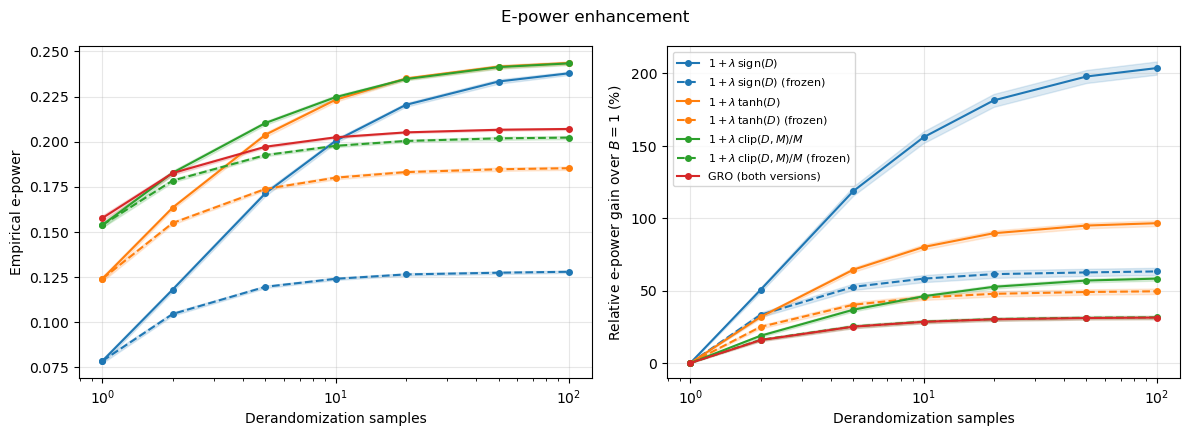


under the null beta = 0   (E[e] <= 1, e-power <= 0)
  1 + 0.6 sign(D)          K=1: mean(e) = 1.0020, e-power = -2.21e-01   |   K=20: mean(e) = 1.0005, e-power = -7.51e-02
  1 + 0.8 tanh(D)          K=1: mean(e) = 1.0029, e-power = -2.77e-01   |   K=20: mean(e) = 1.0009, e-power = -1.24e-01
  GRO (difference)         K=1: mean(e) = 1.0011, e-power = -2.50e-01   |   K=20: mean(e) = 1.0006, e-power = -1.26e-01
  GRO (exchangeability)    K=1: mean(e) = 1.0011, e-power = -2.50e-01   |   K=20: mean(e) = 1.0006, e-power = -1.26e-01

density checks for beta=1.5, beta_hat=0.7
  int int f(q,q~)          = 1.000000  (target 1)
  int f_D(d) dd            = 1.000000  (target 1)
  int d f_D(d) dd          = 2.100000  (theory 2.1000, MC 2.1079)
  max |log f(q~|q) - (log f - log f_q)| = 1.95e-14
  tail-probability check (analytic vs MC):
    [ -6.0, -2.0)   0.01678   0.01627
    [ -2.0, -0.5)   0.09419   0.09365
    [ -0.5,  0.5)   0.32944   0.33013
    [  0.5,  2.0)   0.22528   0.22518
    [  2.0, 

In [4]:
# --- 1. how e-power and the tuned (lambda*, M*) move with the number of X_tilde draws
model = Model(beta=1.0, beta_hat=1.0)
K_LIST = [1, 2, 5, 10, 20, 50, 100]
n_sweep = 8_000
n_pretrain_sweep = 20_000
lam_grid = np.linspace(-0.99, 0.99, 100)   # step 0.02, capped at |lambda| <= 0.99 (see §6)
m_grid = np.linspace(0.5, 10.0, 20)

n_seeds_sweep = 10

# per seed: one pretraining and one evaluation draw with max(K_LIST) columns; smaller K uses
# the first K columns, so all K share randomness.  The frozen arm reuses the K = 1 parameters.
sweep_runs = {K_: [] for K_ in K_LIST}
for s in range(n_seeds_sweep):
    rng = np.random.default_rng([7, s])
    q_pre, q_tilde_pre = simulate(model, n_pretrain_sweep, max(K_LIST), rng)   # tuning only
    q, q_tilde = simulate(model, n_sweep, max(K_LIST), rng)                    # evaluation only
    params_1 = tune(q_pre, q_tilde_pre[:, :1], lam_grid, m_grid)
    for K_ in K_LIST:
        sweep_runs[K_].append(run_arms(q_pre, q_tilde_pre[:, :K_], q, q_tilde[:, :K_],
                                       model, lam_grid, m_grid, params_1=params_1))
sweep = {K_: summarize(sweep_runs[K_], model) for K_ in K_LIST}

####
import pickle
with open("sweep_results.pkl", "wb") as f:
    pickle.dump(dict(sweep=sweep, K_LIST=K_LIST, n_seeds_sweep=n_seeds_sweep), f)

####

print(f"beta = {model.beta}, beta_hat = {model.beta_hat}, n = {n_sweep} (evaluation), "
      f"n_pretrain = {n_pretrain_sweep}, seeds = {n_seeds_sweep};  mean ± SE over seeds\n")
for arm, title in [("retuned", "arm A (re-tuned) and arm C (GRO)"),
                   ("frozen", "arm B (frozen at the K = 1 parameters)")]:
    methods = METHODS if arm == "retuned" else ANTISYMMETRIC
    print(f"e-power, {title}")
    print(f"{'K':>5} " + " ".join(f"{LABELS[m]:>21}" for m in methods))
    for K_ in K_LIST:
        print(f"{K_:>5} " + " ".join(f"{fmt(sweep[K_][m][arm]):>21}" for m in methods))
    print()
print("tuned parameters, re-tuned arm (mean over seeds)")
print(f"{'K':>5} {'lam* sign':>10} {'lam* tanh':>10} {'lam* clip':>10} {'M* clip':>9}")
for K_ in K_LIST:
    r = sweep[K_]
    print(f"{K_:>5} {r['sign']['lam_retuned'][0]:10.2f} {r['tanh']['lam_retuned'][0]:10.2f} "
          f"{r['clip']['lam_retuned'][0]:10.2f} {r['clip']['M_retuned'][0]:9.2f}")


with open("sweep_results.pkl", "rb") as f:
    saved = pickle.load(f)
sweep, K_LIST, n_seeds_sweep = saved["sweep"], saved["K_LIST"], saved["n_seeds_sweep"]

ANTISYMMETRIC = ["sign", "tanh", "clip"]
PLOTTED = ANTISYMMETRIC + ["gro_diff"]           # GRO (exch) is identical to GRO (diff)
PLOT_LABELS = {"sign": r"$1+\lambda\,\mathrm{sign}(D)$",
               "tanh": r"$1+\lambda\,\tanh(D)$",
               "clip": r"$1+\lambda\,\mathrm{clip}(D,M)/M$",
               "gro_diff": "GRO (both versions)"}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
for m, color in zip(PLOTTED, plt.rcParams["axes.prop_cycle"].by_key()["color"]):
    for arm, ls in [("retuned", "-"), ("frozen", "--")]:
        if arm == "frozen" and m not in ANTISYMMETRIC:
            continue                                   # GRO: frozen == re-tuned
        label = PLOT_LABELS[m] + (" (frozen)" if arm == "frozen" else "")
        for ax, key, scale in [(axes[0], arm, 1.0), (axes[1], "gain_" + arm, 100.0)]:
            mu = np.array([sweep[K_][m][key][0] for K_ in K_LIST]) * scale
            se = np.array([sweep[K_][m][key][1] for K_ in K_LIST]) * scale
            ax.plot(K_LIST, mu, ls=ls, marker="o", ms=4, color=color, label=label)
            ax.fill_between(K_LIST, mu - se, mu + se, color=color, alpha=0.15)
for ax in axes:
    ax.set_xscale("log")
    ax.set_xlabel("Derandomization samples")
    ax.grid(alpha=0.3)
axes[0].set_ylabel("Empirical e-power")
axes[1].set_ylabel(r"Relative e-power gain over $B=1$ (%)")
axes[1].legend(fontsize=8)
fig.suptitle("E-power enhancement")
plt.tight_layout()
plt.show()

# --- 2. validity: the derandomized e-variables are still e-variables under the null beta = 0
null = Model(beta=0.0, beta_hat=1.0)
alt = Model(beta=1.0, beta_hat=1.0)      # e-variables built for the alternative
q0, qt0 = simulate(null, 200_000, 20, np.random.default_rng(99))
D0 = qt0 - q0[:, None]
cases = {"1 + 0.6 sign(D)": 1.0 + 0.6 * np.sign(D0),
         "1 + 0.8 tanh(D)": 1.0 + 0.8 * np.tanh(D0),
         "GRO (difference)": e_gro_diff(D0, alt),
         "GRO (exchangeability)": e_gro_exch(q0[:, None], qt0, alt)}
print("\nunder the null beta = 0   (E[e] <= 1, e-power <= 0)")
for name, e in cases.items():
    print(f"  {name:24s} K=1: mean(e) = {e[:, 0].mean():.4f}, e-power = {e_power(e[:, 0]):+.2e}"
          f"   |   K=20: mean(e) = {e.mean(1).mean():.4f}, e-power = {e_power(e.mean(1)):+.2e}")

# --- 3. the analytic densities themselves
chk = Model(beta=1.5, beta_hat=0.7)
qc, qtc = simulate(chk, 200_000, 1, np.random.default_rng(5))
Dc = (qtc - qc[:, None]).ravel()
print(f"\ndensity checks for beta={chk.beta}, beta_hat={chk.beta_hat}")
print("  int int f(q,q~)          = %.6f  (target 1)"
      % integrate.dblquad(lambda u, v: joint_pdf(u * u, v * v, chk) * 4 * u * v,
                          0, np.inf, lambda _: 0.0, lambda _: np.inf)[0])
print("  int f_D(d) dd            = %.6f  (target 1)" % quad_real_line(lambda d: diff_pdf(d, chk)))
print("  int d f_D(d) dd          = %.6f  (theory %.4f, MC %.4f)"
      % (quad_real_line(lambda d: d * diff_pdf(d, chk)), 2 * chk.beta * chk.beta_hat, Dc.mean()))
print("  max |log f(q~|q) - (log f - log f_q)| = %.2e"
      % np.abs(joint_logpdf(qc[:500], qtc[:500, 0], chk) - marginal_q_logpdf(qc[:500], chk)
               - conditional_logpdf(qtc[:500, 0], qc[:500], chk)).max())
print("  tail-probability check (analytic vs MC):")
for lo, hi in [(-6, -2), (-2, -0.5), (-0.5, 0.5), (0.5, 2), (2, 6)]:
    pa = integrate.quad(lambda d: diff_pdf(d, chk), lo, hi, limit=200)[0]
    pe = np.mean((Dc >= lo) & (Dc < hi))
    print(f"    [{lo:5.1f},{hi:5.1f})  {pa:8.5f}  {pe:8.5f}")
e1 = e_gro_diff(Dc, chk)
e2 = e_gro_exch(qc[:, None], qtc, chk).ravel()
print("  max |e_GRO_diff - e_GRO_exch|        = %.2e" % np.abs(e1 - e2).max())
print("  max |e_GRO_diff - 2*sigmoid(kappa D)|= %.2e"
      % np.abs(e1 - 2 * expit(chk.tilt * Dc)).max())